<a href="https://colab.research.google.com/github/zebanahvi/machine-learning-projects/blob/main/SupportVectorMachines.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from pandas import read_csv
from matplotlib import pyplot
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

# Load dataset
filePath = '/content/'
filename = 'wine.csv'
names = ['class','alcohol','malic acid','ash','alcalinity of ash','magnesium',
         'total phenols', 'flavanoids','nonflavanoid phenols','proanthocyanins',
         'color intensity', 'hue', 'OD280/OD315 of diluted wines', 'proline']
dataframe = read_csv(filePath + filename)
array = dataframe.values
X = array[:,1:13]
Y = array[:,0]

# Standardize data
scaler = StandardScaler().fit(X)
rescaledX = scaler.transform(X)

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.multiclass import OneVsOneClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.2, shuffle = True, random_state = 0)

models = []

rnd_clf = RandomForestClassifier(n_estimators=500, max_depth = 2, n_jobs=-1,
random_state=42)

ada_clf = AdaBoostClassifier(
DecisionTreeClassifier(max_depth=1), n_estimators=200,
algorithm="SAMME", learning_rate=0.5, random_state=42)

#svc = OneVsOneClassifier(SVC(kernel = 'rbf', degree = 2, C=1.0, probability=True ,random_state=1, max_iter=1000000))
svc = SVC(kernel = 'rbf', degree = 2, C=1.0, probability=True ,random_state=1, max_iter=1000000, decision_function_shape='ovo')

models.append(('rnd_clf', rnd_clf))
rnd_clf.fit(X_train, y_train)
y_pred_rnd = rnd_clf.predict(X_test)
print(f'Random Forest: {accuracy_score(y_test, y_pred_rnd)}')

models.append(('ada_clf', ada_clf))
ada_clf.fit(X_train, y_train)
y_pred_ada = ada_clf.predict(X_test)
print(f'AdaBoost: {accuracy_score(y_test, y_pred_ada)}')

models.append(('svc', svc))
svc.fit(X_train, y_train)
y_pred_svc = svc.predict(X_test)
print(f'SVC (OvO): {accuracy_score(y_test, y_pred_svc)}')

Random Forest: 1.0


/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


AdaBoost: 0.9444444444444444
SVC (OvO): 0.6388888888888888


rnd_clf: 0.954902 (0.041769)


/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 

ada_clf: 0.932680 (0.054315)
svc: 0.547712 (0.092018)


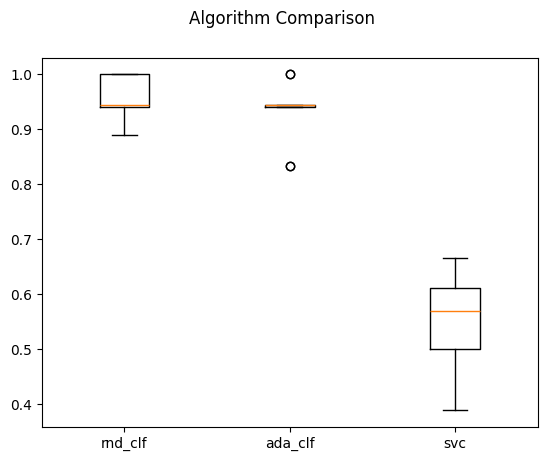

'\nHOMEWORK COMMENTARY:\nCompared to the Random Forest Classifier and AdaBoost Classifier, the Support\nVector Classifier performed worse at around 0.64 . (However, if C is set to\n100.0, the SVC model performs much better with a mean accuracy of over 0.90.)\n'

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from matplotlib import pyplot

results = []
names = []


for name, mod in models:
  kfold = KFold(n_splits = 10, random_state = 7, shuffle = True)
  cv_results = cross_val_score(mod, X, Y, cv = kfold, scoring = 'accuracy')
  results.append(cv_results)
  names.append(name)
  msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
  print(msg)

# boxplot algorithm comparison
fig = pyplot.figure()
fig.suptitle('Algorithm Comparison')
ax = fig.add_subplot(111)
pyplot.boxplot(results)
ax.set_xticklabels(names)
pyplot.show()

"""
HOMEWORK COMMENTARY:
Compared to the Random Forest Classifier and AdaBoost Classifier, the Support
Vector Classifier performed worse at around 0.64 . (However, if C is set to
100.0, the SVC model performs much better with a mean accuracy of over 0.90.)
"""

[(np.float64(1.0), np.float64(2.0)), (np.float64(1.0), np.float64(3.0)), (np.float64(2.0), np.float64(3.0))]

Macro-averaged One vs One ROC AUC Score: 0.84


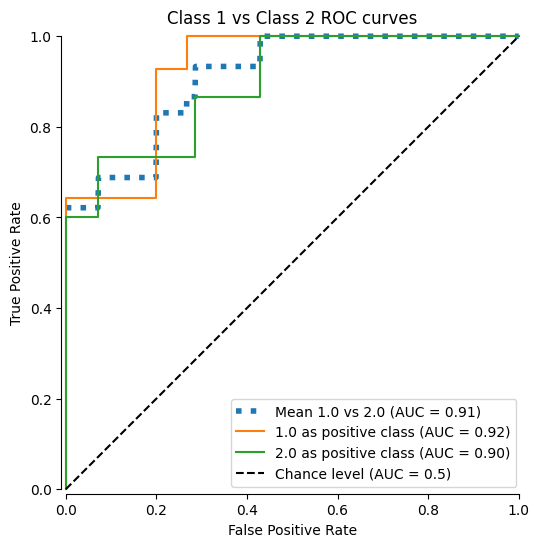

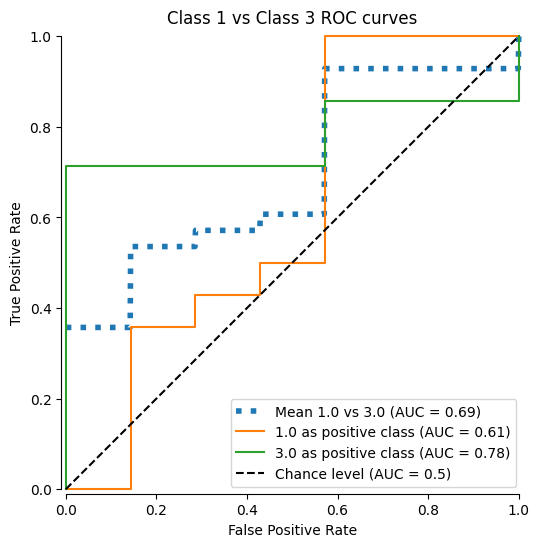

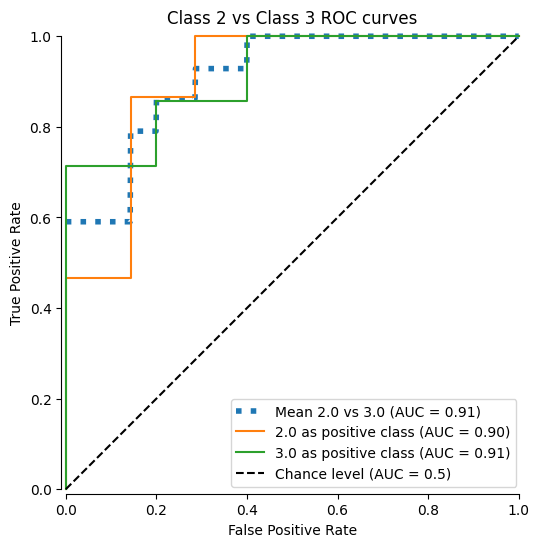

In [ ]:
from itertools import combinations
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import RocCurveDisplay, auc, roc_curve
from sklearn.preprocessing import LabelBinarizer
import numpy as np

# binarize the data for classification from integers (1,2,3) to (0, 1)
label_binarizer = LabelBinarizer().fit(y_train)

# predict probabilities for each class
y_score = svc.fit(X_train, y_train).predict_proba(X_test)

# One Vs One --> pairwise comparisions (1-2, 1-3, 2-3)
pair_list = list(combinations(np.unique(Y), 2))
print(pair_list)

pair_scores = []
mean_tpr = dict()

# iterating through each pairwise class group
for index, (label_a, label_b) in enumerate(pair_list):
  # Identifying the rows that are classified as either label_a or label_b (the current desired classes for comparison)
  a_mask = y_test == label_a
  b_mask = y_test == label_b
  ab_mask = np.logical_or(a_mask, b_mask)

  a_true = a_mask[ab_mask]
  b_true = b_mask[ab_mask]

  #identify the index at which the probability scores for the 2 chosen classes are stored
  idx_a = np.flatnonzero(label_binarizer.classes_ == label_a)[0]
  idx_b = np.flatnonzero(label_binarizer.classes_ == label_b)[0]

  # calculate the fpr and tpr of each of the 2 classes
  fpr_a, tpr_a, _ = roc_curve(a_true, y_score[ab_mask, idx_a])
  fpr_b, tpr_b, _ = roc_curve(b_true, y_score[ab_mask, idx_b])

  # Calculate the mean tpr and mean auc of the 2 classes
  fpr_grid = np.linspace(0.0, 1.0, 1000)
  mean_tpr[index] = np.zeros_like(fpr_grid)
  mean_tpr[index] += np.interp(fpr_grid, fpr_a, tpr_a)
  mean_tpr[index] += np.interp(fpr_grid, fpr_b, tpr_b)
  mean_tpr[index] /= 2
  mean_score = auc(fpr_grid, mean_tpr[index])
  pair_scores.append(mean_score)

  # plot the graph - ROC curve
  fig, ax = plt.subplots(figsize=(6,6))
  plt.plot(
      fpr_grid,
      mean_tpr[index],
      label=f'Mean {label_a} vs {label_b} (AUC = {mean_score:.2f})',
      linestyle=':',
      linewidth=4,
  )
  # roc curve when label_a is positive
  RocCurveDisplay.from_predictions(
      a_true,
      y_score[ab_mask, idx_a],
      ax=ax,
      name=f'{label_a} as positive class',
  )
  # roc curve when label_b is positive
  RocCurveDisplay.from_predictions(
      b_true,
      y_score[ab_mask, idx_b],
      ax = ax,
      name=f'{label_b} as positive class',
      plot_chance_level=True,
      despine=True,
  )
  # chart and axis titles
  ax.set(
      xlabel = 'False Positive Rate',
      ylabel = 'True Positive Rate',
      title=f'Class {int(label_a)} vs Class {int(label_b)} ROC curves',
  )
# displaying the average of the pairwise AUC scores
print(f'\nMacro-averaged One vs One ROC AUC Score: {np.average(pair_scores):.2f}')

# Learning source: https://scikit-learn.org/stable/auto_examples/model_selection/plot_roc.html